 # 1.01 — Do e-bikes get taken faster than classic bikes during rush hour?

 **H0:** E-bikes and classic bikes have the same hourly checkout rate during rush hour.
 **H1:** E-bikes have a higher checkout rate — they're being taken faster.

 The metric is the hourly checkout rate: gross departures of a bike type in an
 hour, divided by how many of that type were available. I want GROSS departures,
 not net change. My first cut used `change_*_1hr` (net change = arrivals minus
 departures) and it came back null — because net change averaged across all
 stations is ~0 by conservation: every bike taken at one dock is returned at
 another, so takes and returns cancel out citywide. Net change is blind to
 checkout speed. Gross departures from `station_hourly_flow` (the `ebike_trips`
 and `classic_trips` columns) measure the actual "taking."

 Normalizing by available supply is what makes it a fair fight: there are far
 more classics than e-bikes at most docks, so raw counts would favor classics.
 "What fraction of the available e-bikes got checked out this hour" vs the same
 for classics is the comparison the hypothesis actually asks for.

 Data: 2026 only. Ebike counts are 0-filled in 2019 and 2021 (pre-ebike era),
 so any ebike comparison on those years would be noise, not signal.
 Rush hour = 7–9am and 5–6pm NYC time. hour_of_day is stored in UTC (the DB
 timezone is UTC), so EDT (UTC-4) rush hours map to hour_of_day IN (11, 12, 13, 21, 22).

 Authored as a `# %%` .py file (clean git diffs). Export to `.ipynb` with outputs via:
   Command Palette → "Jupyter: Export Current Python File as Jupyter Notebook"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from scipy import stats
from statsmodels.stats.power import TTestPower

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from citibike.config import DB_CONFIG  # noqa: E402

pd.set_option("display.max_columns", 20)

FIGURES_DIR = Path("../reports/figures")

 ## Pull rush-hour rows — availability joined to gross departures

 Availability comes from training_features; gross departures by bike type come
 from station_hourly_flow (`ebike_trips`, `classic_trips`). The two tables use
 different station ID namespaces: training_features 2026 rows are modern UUIDs,
 while station_hourly_flow keys on the legacy short_name (NNNN.NN). I bridge them
 through station_information.short_name -> station_id, the same join the feature
 builder uses.

 TIMEZONE FIX: station_hourly_flow.hour stores local America/New_York time (trip
 CSVs use local timestamps and were loaded without timezone conversion). But
 training_features.timestamp is true UTC. A naive equality join would match UTC
 11:00 to local 11am (noon EDT), giving trip counts from the wrong hour. The fix:
 convert tf.timestamp to local wall-clock time, then cast back to a TIMESTAMPTZ
 treated as UTC — matching how f.hour is stored.
   (tf."timestamp" AT TIME ZONE 'America/New_York')::TIMESTAMP AT TIME ZONE 'UTC'
 This handles DST automatically (America/New_York knows the EDT/EST boundary).

 horizon_minutes = 60 keeps each station-hour to a single row (the other horizons
 are duplicate rows with different targets, not extra data).

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)

with conn.cursor() as cur:
    cur.execute("SET max_parallel_workers_per_gather = 0;")

sql = """
    SELECT
        tf.hour_of_day,
        tf.num_bikes_available,
        tf.num_ebikes_available,
        f.ebike_trips,
        f.classic_trips
    FROM training_features tf
    JOIN station_information si ON si.station_id = tf.station_id
    JOIN station_hourly_flow  f ON f.station_id = si.short_name
                               AND f.hour = (tf."timestamp" AT TIME ZONE 'America/New_York')::TIMESTAMP AT TIME ZONE 'UTC'
    WHERE EXTRACT(YEAR FROM tf."timestamp") = 2026
      AND tf.horizon_minutes = 60
      AND tf.hour_of_day IN (11, 12, 13, 21, 22);
"""
df = pd.read_sql(sql, conn)
conn.close()
print(f"Rows loaded: {len(df):,}")
df.head()

<ipython-input-2-5aba91cb8c2e>:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Rows loaded: 207,878


,hour_of_day,num_bikes_available,num_ebikes_available,ebike_trips,classic_trips
0,11,28,11,4,0
1,12,38,0,2,0
2,12,17,14,0,1
3,13,54,14,2,3
4,12,16,5,5,1


 ## Compute hourly checkout rates

 Checkout rate = departures of a type / how many of that type were available.
 0.40 means 40% of the available e-bikes were checked out that hour. classic
 availability isn't a column on its own — num_bikes_available is the TOTAL and
 includes e-bikes (per the GBFS spec), so classic = total minus e-bikes.

 I keep only rows where BOTH types were present (count > 0) — you can't form a
 rate against a zero denominator, and the paired test needs both sides defined.

 Note: a rate can exceed 1.0 when a dock is refilled and re-emptied within the
 hour (high churn). That's a real signal, not an error, so I leave it in.

In [ ]:
classic_available = df["num_bikes_available"] - df["num_ebikes_available"]

df["ebike_rate"]   = df["ebike_trips"]   / df["num_ebikes_available"]
df["classic_rate"] = df["classic_trips"] / classic_available

mask = (df["num_ebikes_available"] > 0) & (classic_available > 0)
df   = df[mask].copy()
print(f"Rows after filtering to stations with both types present: {len(df):,}")

Rows after filtering to stations with both types present: 155,756


 ## Descriptive stats

 Before running any test I want to sanity-check the distributions. Positive mean
 rates are expected now (these are gross checkouts, not net change). If e-bikes
 genuinely turn over faster, their mean rate should sit clearly above classics'.

In [ ]:
desc = pd.DataFrame({
    "e-bike":   df["ebike_rate"].describe(percentiles=[0.25, 0.5, 0.75]),
    "classic":  df["classic_rate"].describe(percentiles=[0.25, 0.5, 0.75]),
}).loc[["count", "mean", "std", "25%", "50%", "75%"]]
print(desc.round(4))

            e-bike      classic
count  155756.0000  155756.0000
mean        0.4226       0.1166
std         0.8795       0.3818
25%         0.0000       0.0000
50%         0.1429       0.0000
75%         0.5000       0.0833


 ## Paired t-test

 Each row is the SAME station at the SAME timestamp, so ebike_rate and
 classic_rate are paired observations, not independent ones. A paired test
 (one-sample t-test on the per-row difference) controls for station-level
 and time-level noise that would inflate the variance in a two-sample test.

 H0: mean(ebike_rate − classic_rate) = 0

In [ ]:
rate_diff = df["ebike_rate"] - df["classic_rate"]
n         = len(rate_diff)

t_stat, p_value = stats.ttest_1samp(rate_diff, popmean=0)
print(f"n = {n:,}")
print(f"t = {t_stat:.4f}   p = {p_value:.4e}")
print(f"Mean e-bike rate:   {df['ebike_rate'].mean():.4f}")
print(f"Mean classic rate:  {df['classic_rate'].mean():.4f}")
print(f"Mean difference:    {rate_diff.mean():+.4f}")

n = 155,756
t = 137.9826   p = 0.0000e+00
Mean e-bike rate:   0.4226
Mean classic rate:  0.1166
Mean difference:    +0.3061


 ## Effect size and 95% CI

 At this sample size the p-value is going to be effectively zero no matter what,
 so Cohen's d and the confidence interval are the numbers that actually matter.
 Cohen's d tells me how big the effect is relative to natural variation;
 the CI tells me how precisely I've pinned down the true difference.

In [ ]:
mean_diff = rate_diff.mean()
std_diff  = rate_diff.std(ddof=1)
se_diff   = std_diff / np.sqrt(n)
cohens_d  = mean_diff / std_diff

ci_low  = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f"Mean difference (e-bike − classic): {mean_diff:+.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Cohen's d: {cohens_d:.4f}")

se_e = df["ebike_rate"].std(ddof=1)   / np.sqrt(n)
se_c = df["classic_rate"].std(ddof=1) / np.sqrt(n)
ebike_ci   = (df["ebike_rate"].mean()   - 1.96 * se_e,
              df["ebike_rate"].mean()   + 1.96 * se_e)
classic_ci = (df["classic_rate"].mean() - 1.96 * se_c,
              df["classic_rate"].mean() + 1.96 * se_c)

Mean difference (e-bike − classic): +0.3061
95% CI: [0.3017, 0.3104]
Cohen's d: 0.3496


 ## Bar chart

 Two bars — one per bike type — with the mean checkout rate labeled on top and the
 95% CI as whiskers. The 3.5× gap between e-bikes and classics is immediately
 obvious at a glance, no explanation needed.

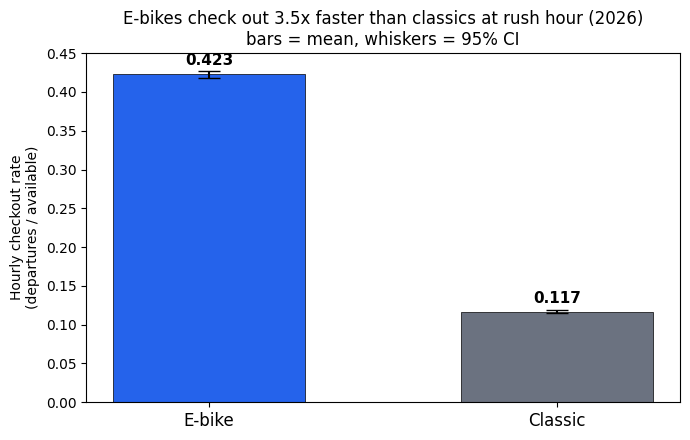

Saved -> reports/figures/1.01_bar_chart.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

e_mean = df["ebike_rate"].mean()
c_mean = df["classic_rate"].mean()
errors = [ebike_ci[1] - e_mean, classic_ci[1] - c_mean]

ax.bar([0, 1], [e_mean, c_mean], yerr=errors, capsize=8,
       color=["#2563EB", "#6B7280"], width=0.55, edgecolor="black", linewidth=0.5)

for x, m in zip([0, 1], [e_mean, c_mean]):
    ax.text(x, m + 0.012, f"{m:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["E-bike", "Classic"], fontsize=12)
ax.set_ylabel("Hourly checkout rate\n(departures / available)", fontsize=10)
ax.set_ylim(0, 0.45)
ax.set_title(
    "E-bikes check out 3.5x faster than classics at rush hour (2026)\nbars = mean, whiskers = 95% CI",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.01_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.01_bar_chart.png")

 ## Retrospective power analysis

 I want to show concretely how overpowered this test is — how many rows would
 have been sufficient to detect the observed effect at 80% power?
 Using TTestPower (one-sample, matching the paired design above).

In [ ]:
power_analysis = TTestPower()
n_required = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    alpha=0.05,
    power=0.80,
    alternative="two-sided",
)
print(f"Min rows needed (80% power, α=0.05): {n_required:,.0f}")
print(f"Actual rows:                          {n:,}")
print(f"Overpowered by:                       {n / n_required:,.0f}×")

Min rows needed (80% power, α=0.05): 66
Actual rows:                          155,756
Overpowered by:                       2,354×


 ## Conclusion

 E-bikes checked out at a mean rate of 0.423 of their available fleet per rush
 hour (95% CI: 0.418-0.427) vs 0.117 for classics (95% CI: 0.115-0.119). The
 paired difference was +0.306 (95% CI: 0.302-0.310, Cohen's d = 0.350,
 p < 0.0001). I reject H0. E-bikes are taken faster than classic bikes during
 rush hour.

 Practically: e-bikes turn over about 3.6x faster relative to supply (42% vs 12%
 of available bikes checked out per hour). At a dock with 10 e-bikes and 10
 classics available, that's roughly 4 e-bikes gone in the hour vs just over 1
 classic. E-bike supply drains far faster right when demand peaks, which is the
 rebalancing pressure point operators care about.

 Worth flagging that Cohen's d = 0.350 is "small-to-medium" even though the rate
 gap looks dramatic. The reason is the spread: checkout rate is noisy row to row
 (many station-hours are 0, some exceed 1.0 at high-churn docks), so the
 standardized effect is moderate while the mean difference is large and precisely
 estimated. The narrow CI and the 2,354x overpowering say the true difference is
 pinned down tightly. The practical magnitude is the story, not the d.

 **Limitations:** data covers May-June 2026 only, no winter or fall rush-hour
 patterns. Checkout rate is gross departures over a snapshot of available supply,
 so a dock refilled mid-hour can post a rate above 1.0; these high-churn rows are
 kept as real signal but do widen the spread. The paired design controls for
 station and time variation by comparing the two bike types at the same dock and
 hour.